# LeetCode #193: Valid Phone Numbers

https://leetcode.com/problems/valid-phone-numbers/

## Comparison of Approaches
| Approach | Time | Space |
|---|---|---|
| grep with regex ★ | O(n) | O(1) |
| awk with regex | O(n) | O(1) |

## Understanding the Methods
### grep with Regex (Optimal Shell)
Use `grep -P` (Perl regex) or `grep -E` (extended regex) to match lines that are valid US phone numbers in the format `(xxx) xxx-xxxx` or `xxx-xxx-xxxx`. The `^` and `$` anchors ensure the entire line matches.

### awk with Regex
Use awk's pattern matching to filter lines matching the same phone number formats. Functionally equivalent.

## Solutions

### C#

In [ ]:
// Shell Problem — Bash solution:
// grep -P '^(\(\d{3}\) |\d{3}-)\d{3}-\d{4}$' file.txt
//
// Alternative using awk:
// awk '/^([0-9]{3}-|\([0-9]{3}\) )[0-9]{3}-[0-9]{4}$/' file.txt

// C# equivalent:
using System;
using System.IO;
using System.Text.RegularExpressions;

var pattern = new Regex(@"^(\(\d{3}\) |\d{3}-)\d{3}-\d{4}$");
foreach (var line in File.ReadAllLines("file.txt")) {
    if (pattern.IsMatch(line)) {
        Console.WriteLine(line);
    }
}

### Python

In [ ]:
import re

def valid_phone_numbers(filename: str) -> list[str]:
    pattern = re.compile(r'^(\(\d{3}\) |\d{3}-)\d{3}-\d{4}$')
    result = []
    with open(filename) as f:
        for line in f:
            line = line.strip()
            if pattern.match(line):
                result.append(line)
    return result

### Go

In [ ]:
package main

import (
    "bufio"
    "fmt"
    "os"
    "regexp"
)

func main() {
    pattern := regexp.MustCompile(`^(\(\d{3}\) |\d{3}-)\d{3}-\d{4}$`)
    file, _ := os.Open("file.txt")
    defer file.Close()
    scanner := bufio.NewScanner(file)
    for scanner.Scan() {
        line := scanner.Text()
        if pattern.MatchString(line) {
            fmt.Println(line)
        }
    }
}

### Rust

In [ ]:
use std::io::{self, BufRead};

fn is_valid_phone(s: &str) -> bool {
    let b = s.as_bytes();
    let check_digits = |slice: &[u8]| -> bool {
        slice.iter().all(|&c| c.is_ascii_digit())
    };
    // Format: (xxx) xxx-xxxx  (length 14)
    if b.len() == 14 && b[0] == b'(' && b[4] == b')' && b[5] == b' '
        && b[9] == b'-' && check_digits(&b[1..4])
        && check_digits(&b[6..9]) && check_digits(&b[10..14]) {
        return true;
    }
    // Format: xxx-xxx-xxxx  (length 12)
    if b.len() == 12 && b[3] == b'-' && b[7] == b'-'
        && check_digits(&b[0..3]) && check_digits(&b[4..7])
        && check_digits(&b[8..12]) {
        return true;
    }
    false
}

fn main() {
    let stdin = io::stdin();
    for line in stdin.lock().lines() {
        let line = line.unwrap();
        if is_valid_phone(&line) {
            println!("{}", line);
        }
    }
}

## Examples

**1. Common Case — Dash Format**
**Input:** `"987-123-4567"`
Matches `xxx-xxx-xxxx`: three digits, dash, three digits, dash, four digits. Length $= 12$, all positions valid.
*Why tricky:* Baseline — the simpler of the two valid formats. Regex: `^\d{3}-\d{3}-\d{4}$`.

**2. Slightly Complex — Parentheses Format**
**Input:** `"(123) 456-7890"`
Matches `(xxx) xxx-xxxx`: open paren, 3 digits, close paren, **space**, 3 digits, dash, 4 digits. Length $= 14$. The mandatory space after `)` is the key detail.
*Why tricky:* Two valid formats — regex alternation `(\(\d{3}\) |\d{3}-)` must accept both. Missing the space after `)` is a common bug.

**3. Edge Case: Time Factor — File with $10^6$ Lines**
**Input:** `file.txt` with 1,000,000 lines, mix of valid and invalid
grep applies the regex line-by-line in $O(L)$ per line where $L \leq 14$. Total $= O(n \times L) = O(14{,}000{,}000)$. No backtracking (fixed-length alternation).
*Why tricky:* Fixed-width regex avoids catastrophic backtracking. Time is strictly $O(n)$ — linear scan.

**4. Edge Case: Space Factor — All Lines Valid (Streaming)**
**Input:** Every line matches `(000) 000-0000` through `(999) 999-9999`
All $n$ lines pass. grep streams output, so peak memory $= O(1)$ buffer. No hash maps or arrays needed.
*Why tricky:* Worst-case output size, but grep is streaming — memory is constant regardless of matches. Space $= O(1)$.

**5. Almost-Impossible but Plausible — Adversarial Near-Misses**
**Input:** `"(123)-456-7890"` | `"(123)456-7890"` | `"123 456 7890"` | `" 987-123-4567"` | `"987-123-4567 "`
Each is off by exactly one character: dash-not-space, missing space, spaces-not-dashes, leading/trailing whitespace. All five must be rejected.
*Why tricky:* The `^` and `$` anchors are essential — without them, a valid substring inside padding would match. Tests boundary precision.

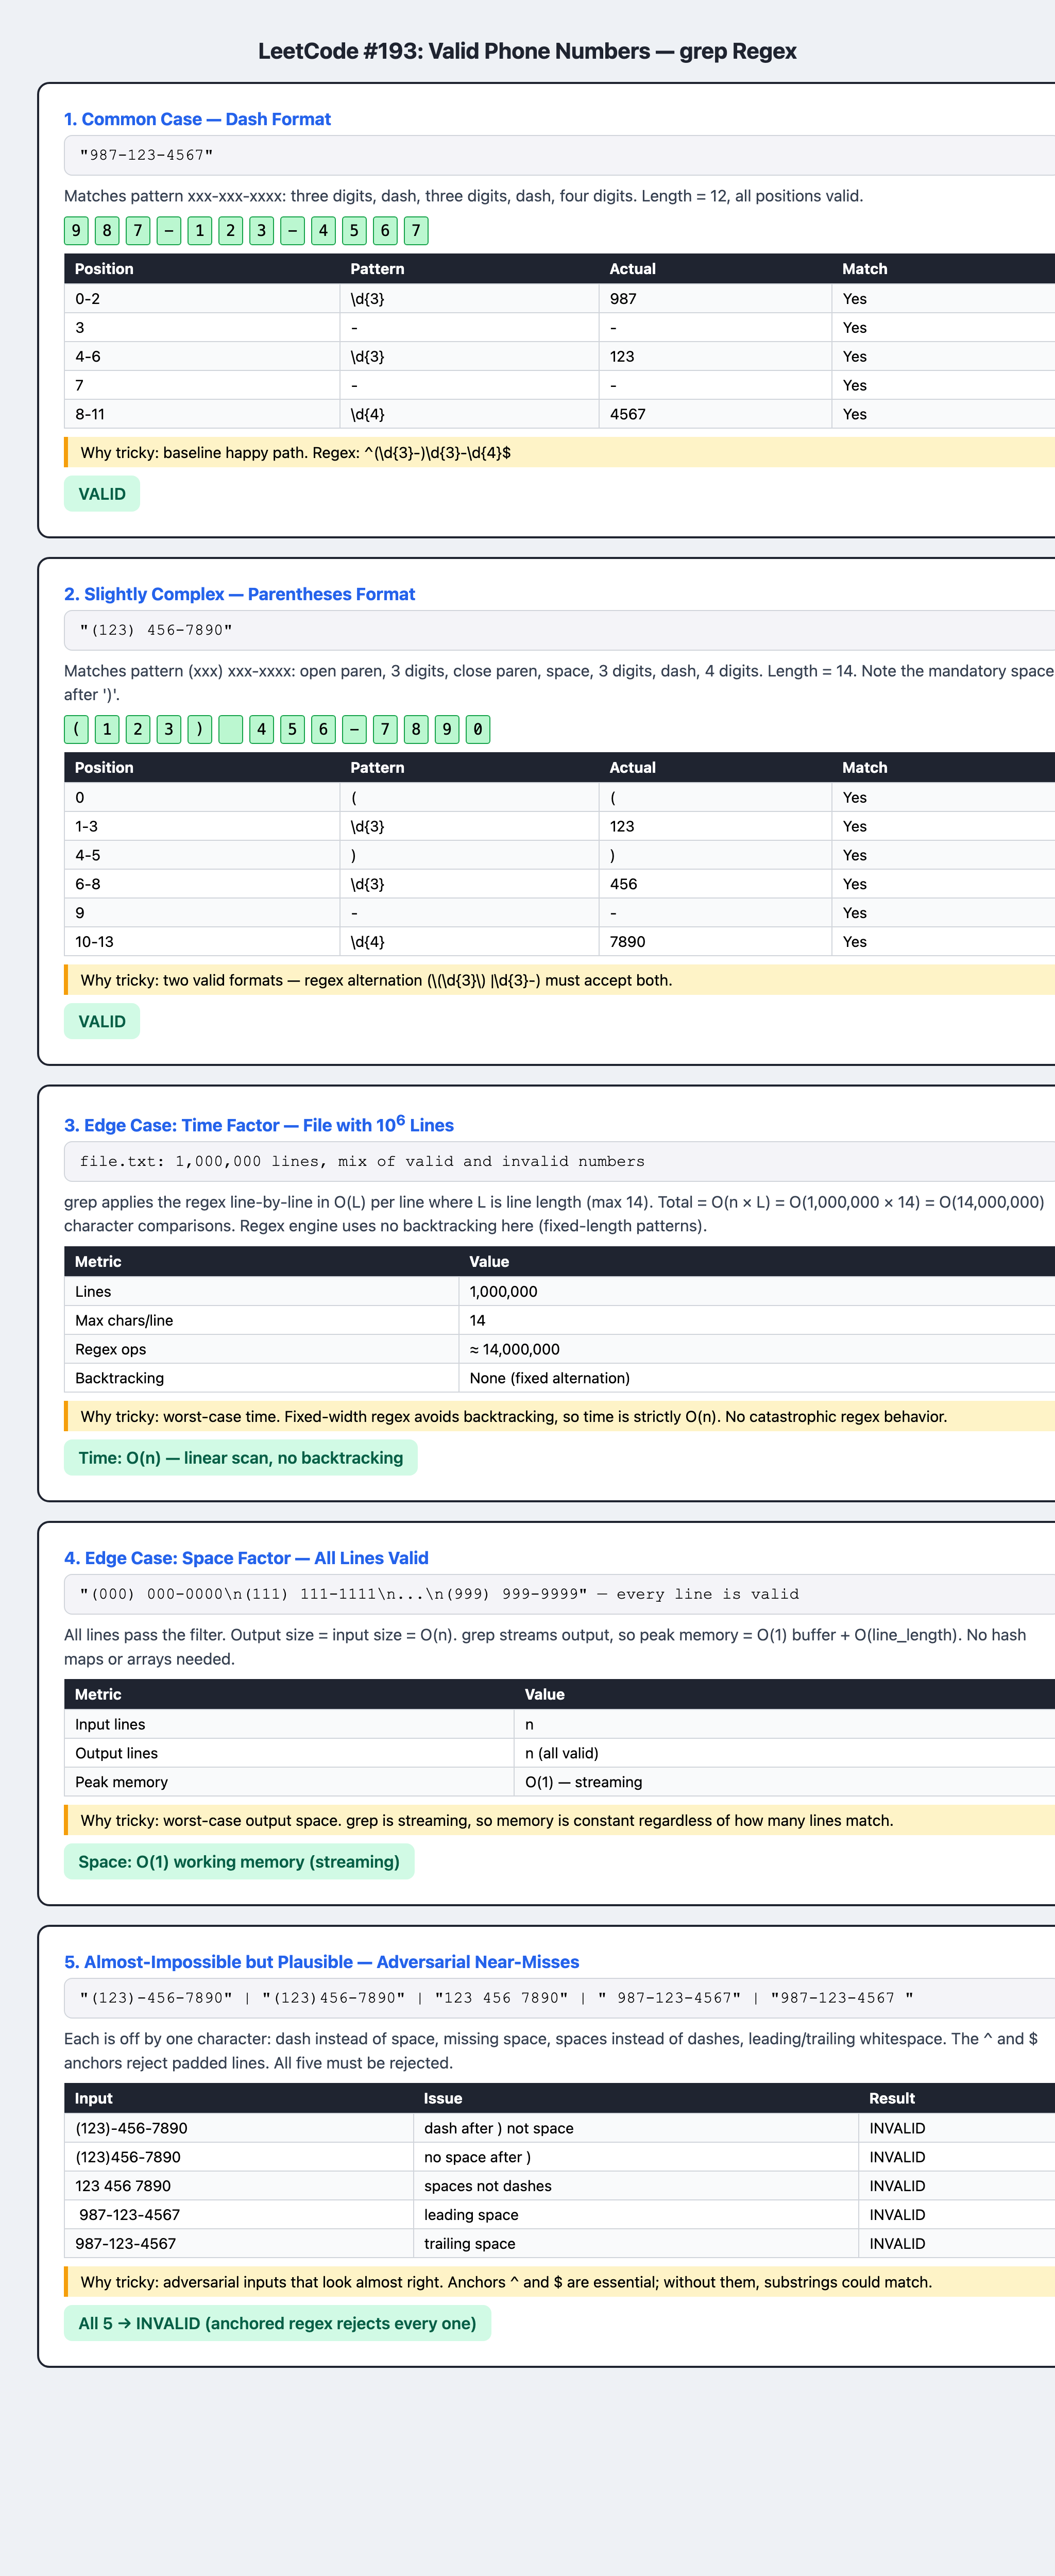